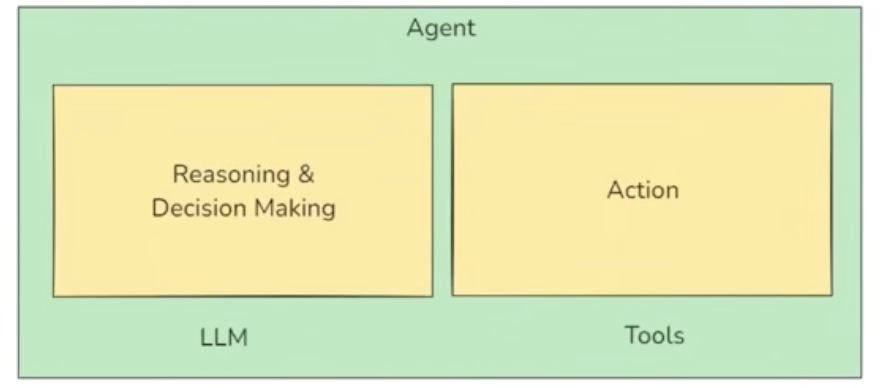

In [23]:
from IPython.display import Image
display(Image(filename="image/tool ecosystem.png", width=400, height=50))


# Capabilities of an AI Agent

An **AI Agent** has two main capabilities:

## 1. Reasoning and Decision-Making Capability

The **LLM provides the reasoning and decision-making capability** of the agent.

The LLM can:

- Understand the user's request
- Analyze the problem
- Decide what needs to be done
- Select the appropriate tool
- Decide the next step based on the result

```text
User Request
      ↓
     LLM
      ↓
   Reasoning
      ↓
    Decision
      ↓
  Select Tool
```
---

## 2. Action Capability

**Tools provide the action capability** of the agent.

Tools allow the agent to interact with the outside world and perform tasks.

Examples:

* Search the web
* Query a database
* Call an API
* Perform calculations
* Read or write files
* Send an email

```text
LLM Decision
      ↓
    Tool
      ↓
Perform Action
      ↓
  Return Result
```

---

# Agent = LLM + Tools

```text
                 AI Agent
                    |
          +---------+---------+
          |                   |
          ↓                   ↓
         LLM                Tools
          |                   |
          ↓                   ↓
  Reasoning & Decision      Action
     Capability           Capability
          |                   |
          +---------+---------+
                    ↓
                  Result
```

## Key Point

> **The LLM provides the reasoning and decision-making capability, while tools provide the action capability.**

### In Simple Words

```text
LLM   → Think & Decide
Tools → Take Action
```


# What is a Tool?

A **tool** is simply a Python function, API, or external service that an LLM can use when it needs to perform a specific task.

Tools allow an AI application to interact with the outside world.

## Examples of Tools

- **Calculator** → Performs calculations
- **Search Engine** → Searches for information
- **Database** → Reads or updates data
- **Weather API** → Gets weather information
- **Email API** → Sends emails
- **Python Function** → Performs a custom task

https://docs.langchain.com/oss/python/integrations/tools

# Built-in Tools vs Custom Tools in LangChain

Tools in LangChain can generally be divided into two categories:

1. **Built-in Tools**
2. **Custom Tools**

---

# 🛠️ 1.Built-in Tools in LangChain

A **built-in tool** is a tool that LangChain already provides for common tasks.

Instead of creating the tool's function logic from scratch, we can simply **import the existing tool and use it**.

## 🔹 Examples of Built-in Tools

| Built-in Tool          | Purpose                            |
| ---------------------- | ---------------------------------- |
| `DuckDuckGoSearchRun`  | 🔎 Search the web using DuckDuckGo |
| `WikipediaQueryRun`    | 📚 Get information from Wikipedia  |
| `PythonREPLTool`       | 🐍 Execute Python code             |
| `ShellTool`            | 💻 Run shell commands              |
| `RequestsGetTool`      | 🌐 Make HTTP GET requests          |
| `GmailSendMessageTool` | 📧 Send emails using Gmail         |
| `SlackSendMessageTool` | 💬 Send messages to Slack          |
| `SQLDatabaseQueryTool` | 🗄️ Execute SQL queries            |

### Example


In [5]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()
results = search_tool.invoke('top news in india today')
print(results)

Hindustan Times: Stay updated with Hindustan Times for the top India news, world events, and breaking stories. Get real-time updates on politics, wars, live cricket scores, entertainment... 8 minutes ago · Today's top India news headlines, news on Indian politics, elections, government, business, technology, and Bollywood. Check today's top 10 news stories, headline news, breaking news, latest news, politics news, sports news, entertainment news and business news on Times of India 18 minutes ago · Stay updated with the latest breaking news, live updates, photos, videos and top trending stories from India and around the world across politics, economy, sports and more on The Economic Times. Get the latest India news, breaking headlines, political developments, government updates, weather alerts, crime news and state coverage at CNBC TV18. Watch India Today Live TV for free – live stream breaking news, latest headlines, politics, sports, entertainment, world and english news streaming onl

In [12]:
print(search_tool.name) #Returns the tool name
print(search_tool.description) #Returns the tool description, usually from the docstring
print(search_tool.args) #Returns the input arguments/schema expected by the tool

duckduckgo_search
A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.
{'query': {'description': 'search query to look up', 'title': 'Query', 'type': 'string'}}


## 2. Custom Tools

**Custom tools** are tools that we create ourself for a specific application.

Usually, we create a Python function and convert it into a LangChain tool using the `@tool` decorator.

### Example

# Steps to Create a Tool Function

### Step 1 – Create a Function and Add a Docstring

Create a function and add a **docstring** that clearly explains the purpose of the function.
The LLM uses the docstring to understand **what the function does and when it should be used**.

### Step 2 – Add Type Hints

Define **type hints** for the function's input parameters and output.
This helps the LLM understand **what type of data the function expects and what it returns**.

### Step 3 – Add the `@tool` Decorator

Use the **`@tool` decorator** to convert the function into a tool.
This tells the LLM that the function is **available as a tool that it can call when needed**.


In [6]:
from langchain_core.tools import tool

In [7]:
# Step 1 - create a function and add doc sting 

def multiply(a, b):
    """Multiply two numbers"""
    return a*b

In [8]:
# Step 2 - add type hints

def multiply(a: int, b:int) -> int:
    """Multiply two numbers"""
    return a*b

In [9]:
# Step 3 - add tool decorator
@tool
def multiply(a: int, b:int) -> int:
    """Multiply two numbers"""
    return a*b

In [10]:
result = multiply.invoke({"a":3, "b":5})
result

15

In [11]:
print(multiply.name) #Returns the tool name
print(multiply.description) #Returns the tool description, usually from the docstring
print(multiply.args) #Returns the input arguments/schema expected by the tool

multiply
Multiply two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [13]:
print(multiply.args_schema.model_json_schema()) 

{'description': 'Multiply two numbers', 'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'multiply', 'type': 'object'}


`print(multiply.args_schema.model_json_schema())` prints the **JSON Schema of the tool's input arguments**,This schema helps the LLM understand what arguments it needs to provide when calling multiply.


```python
{
    'properties': {
        'a': {
            'title': 'A',
            'type': 'integer'
        },
        'b': {
            'title': 'B',
            'type': 'integer'
        }
    },
    'required': ['a', 'b'],
    'title': 'multiply',
    'type': 'object'
}
```


## There are several common ways to create a custom tool.

| Method           | Best for                              |
| ---------------- | ------------------------------------- |
| `@tool`          | Simple Python functions               |
| `StructuredTool` | Custom input schemas and more control |
| `BaseTool`       | Advanced/custom tool behavior         |



### Method 2 – Structured Tool in LangChain

A **Structured Tool** in LangChain is a type of tool where the input follows a **structured schema**, typically defined using a **Pydantic model**.

The schema defines:

* The **input fields**
* The **data types**
* The **required fields**
* The **validation rules**

**Key point:** `StructuredTool` is useful when you need more control over the tool's **input structure and validation**.


In [26]:
from langchain_core.tools import StructuredTool
from pydantic import BaseModel, Field

In [28]:
class MultiplyInput(BaseModel):
    a: int = Field(required=True, description="The first number to add")
    b: int = Field(required=True, description="The second number to add")

/var/folders/yh/qy0zfnfx1rs0kdcl_cd8mrjh0000gn/T/ipykernel_14693/3279971488.py:2: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  a: int = Field(required=True, description="The first number to add")
/var/folders/yh/qy0zfnfx1rs0kdcl_cd8mrjh0000gn/T/ipykernel_14693/3279971488.py:3: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  b: int = Field(required=True, description="The second number to add")


In [33]:
def multiply_func(a: int, b: int) -> int:
    return a * b

In [34]:
multiply_tool = StructuredTool.from_function(
    func=multiply_func,
    name="multiply",
    description="Multiply two numbers",
    args_schema=MultiplyInput
)

In [35]:
result = multiply_tool.invoke({'a':3, 'b':3})

print(result)
print(multiply_tool.name)
print(multiply_tool.description)
print(multiply_tool.args)

9
multiply
Multiply two numbers
{'a': {'description': 'The first number to add', 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to add', 'title': 'B', 'type': 'integer'}}


## Method 3 – Using `BaseTool` Class

`BaseTool` is the **base class for creating custom tools in LangChain**. It defines the core structure and interface that a tool should follow.

We can extend `BaseTool` when you need **full control over the tool's behavior, input handling, and execution logic**.

Other tool implementations, such as `StructuredTool`, follow the tool interface defined by LangChain's core tool abstractions.

### Simple Flow

**BaseTool**
↓
**Create a Custom Tool Class**
↓
**Define Tool Metadata + Execution Logic**
↓
**Tool can be used by the LLM**

### When to Use `BaseTool`

Use `BaseTool` when you need **advanced customization** beyond what `@tool` or `StructuredTool` provides.


In [36]:
from langchain.tools import BaseTool
from typing import Type

In [37]:
# arg schema using pydantic

class MultiplyInput(BaseModel):
    a: int = Field(required=True, description="The first number to add")
    b: int = Field(required=True, description="The second number to add")

/var/folders/yh/qy0zfnfx1rs0kdcl_cd8mrjh0000gn/T/ipykernel_14693/908171234.py:4: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  a: int = Field(required=True, description="The first number to add")
/var/folders/yh/qy0zfnfx1rs0kdcl_cd8mrjh0000gn/T/ipykernel_14693/908171234.py:5: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'required'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  b: int = Field(required=True, description="The second number to add")


In [38]:
class MultiplyTool(BaseTool):
    name: str = "multiply"
    description: str = "Multiply two numbers"

    args_schema: Type[BaseModel] = MultiplyInput

    def _run(self, a: int, b: int) -> int:
        return a * b

In [39]:
multiply_tool = MultiplyTool()

In [40]:
result = multiply_tool.invoke({'a':3, 'b':3})

print(result)
print(multiply_tool.name)
print(multiply_tool.description)

print(multiply_tool.args)

9
multiply
Multiply two numbers
{'a': {'description': 'The first number to add', 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to add', 'title': 'B', 'type': 'integer'}}


## 🧰 Toolkits in LangChain

A **Toolkit** is simply a **collection (bundle) of related tools** that work together for a **common purpose**.

Instead of creating and managing each tool individually, LangChain allows you to group related tools into a **Toolkit** for easier **reuse, organization, and integration**.

### 📦 Example: Google Drive Toolkit

A toolkit could be:

**`GoogleDriveToolkit`**

It may contain multiple tools such as:

```text
GoogleDriveToolkit
│
├── 📄 Search Google Drive
├── 📖 Read Google Drive File
├── ✏️ Create / Update File
├── 📁 List Files
└── 🗑️ Delete File
```

### 🔄 How it works

```text
                ┌──────────────────────┐
                │  GoogleDriveToolkit  │
                └──────────┬───────────┘
                           │
          ┌────────────────┼────────────────┐
          ▼                ▼                ▼
     Search Tool       Read Tool       Create Tool
          │                │                │
          └────────────────┼────────────────┘
                           ▼
                       Google Drive
```

### 💡 Simple way to remember

> **Tool = One capability**
> **Toolkit = Collection of related capabilities**


So, when an **agent needs to work with Google Drive**, we can provide the **whole toolkit**, giving the agent access to multiple related tools rather than adding each tool separately.


In [44]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b


class MathToolkit:
    def get_tools(self):
        return [add, multiply]


# Create toolkit
toolkit = MathToolkit()

# Get tools from toolkit
tools = toolkit.get_tools()

# Inspect tools
for tool in tools:
    print(tool.name, "=>", tool.description)

add => Add two numbers
multiply => Multiply two numbers


## Toolkit Usage

### 1. Create the Toolkit

```python
toolkit = MathToolkit()
````

Creates an instance of the `MathToolkit` class.

### 2. Get All Tools

```python
tools = toolkit.get_tools()
```

Retrieves all the tools available in the toolkit.

**Output:**

```text
[add, multiply]
```

```
```


In [ ]:
              🧰 MathToolkit
                     │
                get_tools()
                     │
             ┌───────┴───────┐
             ▼               ▼
          ➕ add          ✖️ multiply
             │               │
       name: add       name: multiply
       description     description

## 🔗 Tool Binding

**Tool binding** is the process of connecting tools to an LLM so that the LLM **knows which tools are available and can decide when to call them**.

### Simple flow

```text
Tools
  │
  ▼
bind_tools()
  │
  ▼
LLM + Tools
  │
  ▼
User Query
  │
  ▼
LLM decides whether to call a tool
```

### Example


In [50]:
#local ollama
from langchain_ollama import ChatOllama

model = ChatOllama(model="qwen3:4b")
response = model.invoke("the capital of India? in one word")
print(response.content)

Delhi


In [51]:
llm_with_tools = model.bind_tools(tools)

In [55]:
response = llm_with_tools.invoke("What is 10 multiplied by 5?")

print(response.tool_calls)

[{'name': 'multiply', 'args': {'a': 10, 'b': 5}, 'id': 'fced2dde-8e12-4468-a84c-28b4effae522', 'type': 'tool_call'}]


In [62]:
from langchain_core.messages import HumanMessage, ToolMessage
messages = [HumanMessage(content="Can you multiply 3 with 1000?")]
response = llm_with_tools.invoke(messages)
print(response.tool_calls[0])
result = multiply.invoke(response.tool_calls[0]["args"])
result

{'name': 'multiply', 'args': {'a': 3, 'b': 1000}, 'id': '6c9b6cef-f072-49fb-a0b2-c4503a9acb0b', 'type': 'tool_call'}


3000

# 🔧 Complete Flow of Tools in LangChain

The complete tool flow can be understood in **7 steps**:

```text
                 USER
                   │
                   ▼
          📝 HumanMessage
                   │
                   ▼
             🤖 LLM / Model
                   │
            bind_tools()
                   │
                   ▼
        Does the model need a tool?
              /             \
            No               Yes
            │                 │
            ▼                 ▼
      Normal Answer      🔧 Tool Call
                              │
                              ▼
                    ⚙️ Tool Execution
                              │
                              ▼
                       📦 Tool Result
                              │
                              ▼
                    🤖 LLM receives result
                              │
                              ▼
                       💬 Final Answer
````

## 1. Create a Tool

A **Tool** is a function that the LLM can request.

```python
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b
```

We now have two tools:

```text
🛠️ add
🛠️ multiply
```

---

## 2. Create a Toolkit

A **Toolkit** groups related tools together.

```python
class MathToolkit:
    def get_tools(self):
        return [add, multiply]

toolkit = MathToolkit()
```

Conceptually:

```text
        🧰 MathToolkit
              │
       ┌──────┴──────┐
       ▼             ▼
    ➕ add       ✖️ multiply
```

---

## 3. Get All Tools

```python
tools = toolkit.get_tools()
```

The result is:

```python
[add, multiply]
```

You can inspect the tools:

```python
for tool in tools:
    print(tool.name, "=>", tool.description)
```

Output:

```text
add => Add two numbers
multiply => Multiply two numbers
```

---

## 4. Create the LLM

Example using Ollama:

```python
from langchain_ollama import ChatOllama

model = ChatOllama(
    model="qwen3:4b"
)
```

> The selected Ollama model must support **tool calling**.

---

## 5. Bind Tools to the LLM

```python
model_with_tools = model.bind_tools(tools)
```

This is called **Tool Binding**.

It tells the LLM which tools are available:

```text
             🤖 LLM
               │
        ┌──────┴──────┐
        ▼             ▼
     ➕ add       ✖️ multiply
```

> `bind_tools()` makes tools available to the LLM.
> It does **not** execute the tools.

---

## 6. Send the User Message

```python
from langchain_core.messages import HumanMessage

messages = [
    HumanMessage(
        content="Can you multiply 3 with 1000?"
    )
]

response = model_with_tools.invoke(messages)
```

The LLM receives:

```text
HumanMessage
     │
     ▼
"Can you multiply 3 with 1000?"
```

---

## 7. LLM Generates a Tool Call

The LLM decides that it needs the `multiply` tool.

```python
response.tool_calls
```

Example:

```python
[
    {
        "name": "multiply",
        "args": {
            "a": 3,
            "b": 1000
        }
    }
]
```

The LLM is requesting:

```text
multiply(a=3, b=1000)
```

> The LLM **requests** the tool. It does not automatically mean your Python function has executed.

---

## 8. Execute the Tool

Get the tool call:

```python
tool_call = response.tool_calls[0]
```

Execute the tool:

```python
result = multiply.invoke(tool_call["args"])

print(result)
```

Output:

```text
3000
```

Flow:

```text
Tool Call
    │
    ▼
multiply(a=3, b=1000)
    │
    ▼
Python function executes
    │
    ▼
3000
```

---

## 9. Send the Tool Result Back to the LLM

A `ToolMessage` sends the tool result back to the model.

```python
from langchain_core.messages import ToolMessage

tool_message = ToolMessage(
    content=str(result),
    tool_call_id=tool_call["id"]
)
```

Then send the messages back to the LLM:

```python
messages = messages + [
    response,
    tool_message
]

final_response = model_with_tools.invoke(messages)

print(final_response.content)
```

Final output:

```text
3000
```

---

# 🔄 Complete Tool Flow

```text
                    ┌──────────────┐
                    │     USER     │
                    └──────┬───────┘
                           │
                           ▼
                  ┌─────────────────┐
                  │  HumanMessage   │
                  └────────┬────────┘
                           │
                           ▼
                  ┌─────────────────┐
                  │       LLM       │
                  │   ChatOllama    │
                  └────────┬────────┘
                           │
                     bind_tools()
                           │
                           ▼
                ┌─────────────────────┐
                │   Available Tools   │
                │                     │
                │  ➕ add             │
                │  ✖️ multiply        │
                └──────────┬──────────┘
                           │
                           ▼
                    Tool Decision
                           │
                           ▼
                 ┌──────────────────┐
                 │    Tool Call     │
                 │                  │
                 │ multiply         │
                 │ a = 3            │
                 │ b = 1000         │
                 └────────┬─────────┘
                          │
                          ▼
                 ┌──────────────────┐
                 │  Tool Execution  │
                 │                  │
                 │ multiply(3,1000) │
                 └────────┬─────────┘
                          │
                          ▼
                       3000
                          │
                          ▼
                 ┌──────────────────┐
                 │   ToolMessage    │
                 │    result=3000   │
                 └────────┬─────────┘
                          │
                          ▼
                 ┌──────────────────┐
                 │       LLM        │
                 └────────┬─────────┘
                          │
                          ▼
                 ┌──────────────────┐
                 │  Final Answer    │
                 │      3000        │
                 └──────────────────┘
```

# 🧠 Key Concepts

| Concept            | Meaning                               |
| ------------------ | ------------------------------------- |
| **Tool**           | Individual function/capability        |
| **Toolkit**        | Collection of related tools           |
| **Tool Binding**   | Makes tools available to the LLM      |
| **Tool Call**      | LLM requests a specific tool          |
| **Tool Execution** | Application executes the tool         |
| **ToolMessage**    | Sends the tool result back to the LLM |

## ⭐ Easy Way to Remember

```text
User
 ↓
HumanMessage
 ↓
LLM
 ↓
Tool Binding
 ↓
Tool Call
 ↓
Tool Execution
 ↓
ToolMessage
 ↓
LLM
 ↓
Final Answer
```

```
```


In [65]:
# ============================================================
# 1. IMPORTS
# ============================================================

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_ollama import ChatOllama


# ============================================================
# 2. CREATE CUSTOM TOOLS
# ============================================================

@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b


# ============================================================
# 3. CREATE TOOLKIT
# ============================================================

class MathToolkit:

    def get_tools(self):
        return [add, multiply]


# Create toolkit
toolkit = MathToolkit()


# ============================================================
# 4. GET ALL TOOLS FROM TOOLKIT
# ============================================================

tools = toolkit.get_tools()

for tool in tools:
    print(tool.name, "=>", tool.description)


# ============================================================
# 5. CREATE OLLAMA MODEL
# ============================================================

# IMPORTANT:
# Use an Ollama model that supports tool calling.
# gemma3:4b in your setup returned:
# "does not support tools"

model = ChatOllama(model="qwen3:4b")

# ============================================================
# 6. BIND TOOLS TO MODEL
# ============================================================

model_with_tools = model.bind_tools(tools)


# ============================================================
# 7. CREATE HUMAN MESSAGE
# ============================================================

messages = [HumanMessage(content="Can you multiply 3 with 1000?")]


# ============================================================
# 8. INVOKE MODEL
# ============================================================

response = model_with_tools.invoke(messages)

print("\nLLM Response:")
print(response)


# ============================================================
# 9. CHECK WHETHER LLM REQUESTED A TOOL
# ============================================================

print("\nTool Calls:")
print(response.tool_calls)

# ============================================================
# 10. EXECUTE TOOL CALL
# ============================================================

tool_messages = []

for tool_call in response.tool_calls:

    tool_name = tool_call["name"]
    tool_args = tool_call["args"]

    print("\nTool Name:", tool_name)
    print("Tool Arguments:", tool_args)

    # Find the requested tool
    selected_tool = next(
        tool for tool in tools
        if tool.name == tool_name
    )

    # Execute the tool
    result = selected_tool.invoke(tool_args)

    print("Tool Result:", result)

    # ========================================================
    # 11. CREATE TOOL MESSAGE
    # ========================================================

    tool_message = ToolMessage(
        content=str(result),
        tool_call_id=tool_call["id"]
    )

    tool_messages.append(tool_message)


# ============================================================
# 12. SEND TOOL RESULT BACK TO LLM
# ============================================================

messages = messages + [response] + tool_messages


# ============================================================
# 13. GET FINAL ANSWER
# ============================================================

final_response = model_with_tools.invoke(messages)

print("\nFinal Answer:")
print(final_response.content)

add => Add two numbers
multiply => Multiply two numbers

LLM Response:
content='' additional_kwargs={} response_metadata={'model': 'qwen3:4b', 'created_at': '2026-09-26T13:50:10.466913Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8769588209, 'load_duration': 1050112792, 'prompt_eval_count': 186, 'prompt_eval_duration': 341448000, 'eval_count': 338, 'eval_duration': 7373545000, 'logprobs': None, 'model_name': 'qwen3:4b', 'model_provider': 'ollama'} id='lc_run--01a0ddfa-e1e0-7113-8ff6-ef1eb07b1480-0' tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 1000}, 'id': '0d7f5589-383c-41f4-a896-e8d4bd04f9c3', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 186, 'output_tokens': 338, 'total_tokens': 524}

Tool Calls:
[{'name': 'multiply', 'args': {'a': 3, 'b': 1000}, 'id': '0d7f5589-383c-41f4-a896-e8d4bd04f9c3', 'type': 'tool_call'}]

Tool Name: multiply
Tool Arguments: {'a': 3, 'b': 1000}
Tool Result: 3000

Final Answer:
The result of multiplying 3 b

# ToolNode in Lang Graph
**ToolNode** is a pre-built node in LangGraph that acts as a bridge between the graph and external tools. It receives tool calls from the LLM, executes the corresponding tools, and returns their results back to the graph.

**In one line:**

> 🧠 **LLM decides → ToolNode executes → Result goes back to LLM**


In [23]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage

from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import MemorySaver
import requests

In [24]:
# -------------------
# 1. LLM
# -------------------
llm =ChatOllama(model="qwen3:4b")

In [25]:

# -------------------
# 2. Tools
# -------------------
# Tools
search_tool = DuckDuckGoSearchRun(region="us-en")

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}




@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    r = requests.get(url)
    return r.json()



tools = [search_tool, get_stock_price, calculator]
llm_with_tools = llm.bind_tools(tools)

In [26]:
# -------------------
# 3. State
# -------------------
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [27]:
# -------------------
# 4. Nodes
# -------------------
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

## `tools_condition` in LangGraph

> `tools_condition` is a pre-built conditional router in LangGraph that decides whether to send the workflow to `ToolNode` or continue/end based on whether the LLM generated a tool call.

Here:

* **LLM node** → decides whether a tool is required.
* **`tools_condition`** → checks the LLM's response.
* **Tool call exists** → routes to `ToolNode`.
* **No tool call** → routes toward the final answer.

So remember:

**`ToolNode` = Execute the tool 🛠️** <br>
**`tools_condition` = Decide whether to go to the tool 🧭**


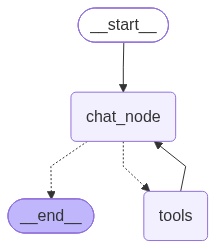

In [28]:
# -------------------
# 6. Graph
# -------------------
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge('tools', 'chat_node')

#create checkpoint for data saving
checkpointer = MemorySaver()
chatbot = graph.compile(checkpointer=checkpointer)
chatbot 

In [29]:
config= {'configurable' :{'thread_id':"1"}}
response=chatbot.invoke({'messages':[HumanMessage(content="hi")]},config=config)
print('AI :' ,response['messages'][-1].content)

AI : Hello! How can I assist you today? 😊


In [ ]:
#define thread
thread_id='1'
while True:
    user_message=input('Type here : ')
    print('User :',user_message)
    if user_message.strip().lower() in ['exit','quit','bye']:
       break   

    config= {'configurable' :{'thread_id':thread_id}}how 
    response=chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
    print('AI :' ,response['messages'][-1].content)

Type here :  hi


User : hi
AI : Hello! How can I assist you today? 😊


Type here :  stock price of apple


User : stock price of apple
AI : The current stock price of Apple (AAPL) is **$341.07** as of the latest trading day (2026-09-25). The price has increased by **$5.15** (1.53%) compared to the previous close. 📈


Type here :  How much would 50 Apple shares cost


User : How much would 50 Apple shares cost
AI : The cost for 50 Apple (AAPL) shares at the current price of **$341.07** would be **$17,053.50**. 📊


Type here :  add 4+5


User : add 4+5
AI : The result of 4 + 5 is **9** 😊


Type here :  add 3 in result


User : add 3 in result
AI : The result of 9 + 3 is **12** 😊
